In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    PrecisionRecallDisplay, RocCurveDisplay
)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')
print("All imports OK")
print(f"XGBoost: {xgb.__version__} | LightGBM: {lgb.__version__}")


All imports OK
XGBoost: 3.2.0 | LightGBM: 4.6.0


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload DataSet.csv

df = pd.read_csv('DataSet.csv')
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['F3924'].value_counts())
print(f"\nMule prevalence: {df['F3924'].mean()*100:.3f}%")

Saving DataSet.csv to DataSet (1).csv
Shape: (9082, 3925)

Target distribution:
F3924
0    9001
1      81
Name: count, dtype: int64

Mule prevalence: 0.892%


In [ ]:
TARGET = 'F3924'
y = df[TARGET]

leaky = []

# --- Numeric leakage: columns that near-perfectly correlate with target ---
num_cols = df.select_dtypes(include='number').columns.drop(TARGET)
print("=== NUMERIC LEAKAGE SCAN ===")
for col in num_cols:
    non_null = df[col].notna()
    if non_null.sum() == 0:
        continue
    match = (df.loc[non_null, col] == y[non_null]).mean()
    if match > 0.90:
        print(f"  🚨 {col}: {match*100:.2f}% match with target → LEAKY")
        leaky.append(col)

# --- Categorical leakage: categories that only appear in one class ---
cat_cols = df.select_dtypes(include='object').columns
print("\n=== CATEGORICAL LEAKAGE SCAN ===")
for col in cat_cols:
    grp = df.groupby(col)[TARGET].mean()
    if (grp == 0).any() or (grp == 1).any():
        # check if any value has 100% of one class exclusively
        for val, purity in grp.items():
            count = (df[col] == val).sum()
            if count > 5 and (purity == 0.0 or purity == 1.0):
                print(f"  🚨 {col}='{val}': {purity:.0%} {'mule' if purity==1 else 'legit'} "
                      f"({count} rows) → LEAKY")
                leaky.append(col)
                break

LEAKY_COLS = list(set(leaky))
print(f"\n>>> Dropping {len(LEAKY_COLS)} leaky columns: {LEAKY_COLS}")

=== NUMERIC LEAKAGE SCAN ===
  🚨 F610: 98.00% match with target → LEAKY
  🚨 F611: 98.92% match with target → LEAKY
  🚨 F612: 98.60% match with target → LEAKY
  🚨 F613: 98.00% match with target → LEAKY
  🚨 F614: 98.92% match with target → LEAKY
  🚨 F615: 98.60% match with target → LEAKY
  🚨 F616: 99.11% match with target → LEAKY
  🚨 F617: 99.11% match with target → LEAKY
  🚨 F618: 99.11% match with target → LEAKY
  🚨 F619: 99.11% match with target → LEAKY
  🚨 F620: 99.11% match with target → LEAKY
  🚨 F621: 99.11% match with target → LEAKY
  🚨 F623: 97.73% match with target → LEAKY
  🚨 F624: 95.75% match with target → LEAKY
  🚨 F626: 97.73% match with target → LEAKY
  🚨 F627: 95.72% match with target → LEAKY
  🚨 F629: 97.97% match with target → LEAKY
  🚨 F630: 96.43% match with target → LEAKY
  🚨 F632: 97.97% match with target → LEAKY
  🚨 F633: 96.40% match with target → LEAKY
  🚨 F635: 97.97% match with target → LEAKY
  🚨 F636: 96.43% match with target → LEAKY
  🚨 F638: 97.97% match wi

In [ ]:
# ── DIAGNOSTIC: understand the leakage structure before proceeding ──────────

leaky_set = set(LEAKY_COLS)

# 1. What's the range of leaky feature indices?
leaky_nums = []
for col in LEAKY_COLS:
    try:
        leaky_nums.append(int(col[1:]))  # strip 'F' prefix
    except:
        pass
leaky_nums.sort()

print(f"Total leaky columns: {len(LEAKY_COLS)}")
print(f"Total columns in dataset: {df.shape[1]}")
print(f"Leaky as % of total: {len(LEAKY_COLS)/df.shape[1]*100:.1f}%")
print(f"\nLeaky feature index range: F{min(leaky_nums)} → F{max(leaky_nums)}")

# 2. Find the NON-leaky features (these are your safe features)
all_features = [c for c in df.columns if c != 'F3924']
safe_features = [c for c in all_features if c not in leaky_set]
print(f"\nSafe (non-leaky) features: {len(safe_features)}")
print(f"\nSafe feature list:")
print(safe_features)

# 3. Check how many of the 18 bank-defined anchor features survived
ANCHOR = ['F115','F321','F527','F531','F670','F1692','F2082','F2122',
          'F2582','F2678','F2737','F2956','F3043','F3836','F3887',
          'F3889','F3891','F3894']
safe_anchors   = [f for f in ANCHOR if f not in leaky_set]
leaky_anchors  = [f for f in ANCHOR if f in leaky_set]
print(f"\nAnchor features SAFE:  {len(safe_anchors)} → {safe_anchors}")
print(f"Anchor features LEAKY: {len(leaky_anchors)} → {leaky_anchors}")

# 4. Check what the safe features look like
print(f"\n── Safe feature value sample ──")
if safe_features:
    print(df[safe_features[:10]].describe().round(2))

Total leaky columns: 782
Total columns in dataset: 3925
Leaky as % of total: 19.9%

Leaky feature index range: F610 → F3923

Safe (non-leaky) features: 3142

Safe feature list:
['Unnamed: 0', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30', 'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40', 'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'F48', 'F49', 'F50', 'F51', 'F52', 'F53', 'F54', 'F55', 'F56', 'F57', 'F58', 'F59', 'F60', 'F61', 'F62', 'F63', 'F64', 'F65', 'F66', 'F67', 'F68', 'F69', 'F70', 'F71', 'F72', 'F73', 'F74', 'F75', 'F76', 'F77', 'F78', 'F79', 'F80', 'F81', 'F82', 'F83', 'F84', 'F85', 'F86', 'F87', 'F88', 'F89', 'F90', 'F91', 'F92', 'F93', 'F94', 'F95', 'F96', 'F97', 'F98', 'F99', 'F100', 'F101', 'F102', 'F103', 'F104', 'F105', 'F106', 'F107', 'F108', 'F109', 'F110', 'F111', 'F112', 'F113', 'F114', 'F11

In [ ]:
# ── CELL 4: PREPROCESSING ────────────────────────────────────────────────────

TARGET = 'F3924'

# 1. Drop leaky columns + row index column
drop_cols = LEAKY_COLS + ['Unnamed: 0']
df2 = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f"After leakage + index drop: {df2.shape}")

# 2. Encode categoricals
cat_cols = df2.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df2[col] = le.fit_transform(df2[col].astype(str))

# 3. Drop 100% NaN columns
all_nan = df2.columns[df2.isnull().all()].tolist()
df2 = df2.drop(columns=all_nan)
print(f"Dropped {len(all_nan)} all-NaN columns")

# 4. Drop zero-variance columns
X_temp = df2.drop(columns=[TARGET]).fillna(0)
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=0.0)
sel.fit(X_temp)
zero_var = X_temp.columns[~sel.get_support()].tolist()
df2 = df2.drop(columns=zero_var)
print(f"Dropped {len(zero_var)} zero-variance columns")

print(f"\n✅ Final shape: {df2.shape}")
print(f"✅ Features for modeling: {df2.shape[1] - 1}")

# 5. Stratified split
X = df2.drop(columns=[TARGET])
y = df2[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos

print(f"\nTrain: {X_train.shape} | Mules: {y_train.sum()}")
print(f"Val:   {X_val.shape}   | Mules: {y_val.sum()}")
print(f"Class ratio (neg/pos): {scale_pos:.1f}x")

# 6. Define safe anchor features (3 were leaky, use the 15 that survived)
BASELINE_COLS = [
    'F115','F321','F527','F531','F1692','F2082','F2122',
    'F2582','F2678','F2737','F2956','F3043','F3836','F3887','F3894'
]
baseline_available = [c for c in BASELINE_COLS if c in X_train.columns]
print(f"\nBaseline anchor features available: {len(baseline_available)}")
print(baseline_available)

After leakage + index drop: (9082, 3142)
Encoding 2 categorical columns: ['F3890', 'F3893']
Dropped 63 all-NaN columns
Dropped 0 zero-variance columns

✅ Final shape: (9082, 3079)
✅ Features for modeling: 3078

Train: (7265, 3078) | Mules: 65
Val:   (1817, 3078)   | Mules: 16
Class ratio (neg/pos): 110.8x

Baseline anchor features available: 15
['F115', 'F321', 'F527', 'F531', 'F1692', 'F2082', 'F2122', 'F2582', 'F2678', 'F2737', 'F2956', 'F3043', 'F3836', 'F3887', 'F3894']


In [ ]:
# ── CELL 5: MODEL A — Baseline (15 anchor features) ─────────────────────────

Xtr_A = X_train[BASELINE_COLS]
Xv_A  = X_val[BASELINE_COLS]

model_A = xgb.XGBClassifier(
    n_estimators      = 1000,
    max_depth         = 4,
    learning_rate     = 0.05,
    scale_pos_weight  = scale_pos,    # 110.8x handles imbalance
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    eval_metric       = 'aucpr',
    early_stopping_rounds = 40,
    random_state      = 42,
    verbosity         = 0,
    tree_method       = 'hist'
)

model_A.fit(
    Xtr_A, y_train,
    eval_set      = [(Xv_A, y_val)],
    verbose       = 100
)

proba_A = model_A.predict_proba(Xv_A)[:, 1]
pred_A  = (proba_A >= 0.5).astype(int)

print("\n========== MODEL A: BASELINE RESULTS ==========")
print(classification_report(y_val, pred_A, target_names=['Legit','Mule']))
print("Confusion Matrix:")
print(confusion_matrix(y_val, pred_A))

roc_A = roc_auc_score(y_val, proba_A)
pr_A  = average_precision_score(y_val, proba_A)
print(f"\nROC AUC : {roc_A:.5f}")
print(f"PR  AUC : {pr_A:.5f}")

# Score separation — critical for understanding model quality
mule_sc  = proba_A[y_val == 1]
legit_sc = proba_A[y_val == 0]
print(f"\nMule  scores → min: {mule_sc.min():.4f} | median: {np.median(mule_sc):.4f} | max: {mule_sc.max():.4f}")
print(f"Legit scores → min: {legit_sc.min():.4f} | median: {np.median(legit_sc):.4f} | max: {legit_sc.max():.4f}")
print(f"Score gap    → {mule_sc.min() - legit_sc.max():.4f}")

# Find optimal threshold
print("\n── Threshold scan ──")
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    p = (proba_A >= thresh).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    print(f"  thresh={thresh:.1f} | precision={precision_score(y_val,p,zero_division=0):.3f} "
          f"| recall={recall_score(y_val,p):.3f} "
          f"| f1={f1_score(y_val,p,zero_division=0):.3f} "
          f"| flagged={p.sum()}")

[0]	validation_0-aucpr:0.05394
[83]	validation_0-aucpr:0.34334

========== MODEL A: BASELINE RESULTS ==========
              precision    recall  f1-score   support

       Legit       1.00      0.91      0.95      1801
        Mule       0.06      0.69      0.11        16

    accuracy                           0.90      1817
   macro avg       0.53      0.80      0.53      1817
weighted avg       0.99      0.90      0.94      1817

Confusion Matrix:
[[1631  170]
 [   5   11]]

ROC AUC : 0.91973
PR  AUC : 0.42248

Mule  scores → min: 0.2596 | median: 0.5874 | max: 0.8359
Legit scores → min: 0.0431 | median: 0.2167 | max: 0.8091
Score gap    → -0.5495

── Threshold scan ──
  thresh=0.1 | precision=0.010 | recall=1.000 | f1=0.021 | flagged=1538
  thresh=0.2 | precision=0.016 | recall=1.000 | f1=0.032 | flagged=997
  thresh=0.3 | precision=0.026 | recall=0.938 | f1=0.051 | flagged=576
  thresh=0.4 | precision=0.040 | recall=0.812 | f1=0.076 | flagged=327
  thresh=0.5 | precision=0.061 |

In [ ]:
# ── CELL 6: MODEL B — Full Feature LightGBM ──────────────────────────────────

model_B = lgb.LGBMClassifier(
    n_estimators      = 2000,
    max_depth         = 5,
    learning_rate     = 0.03,
    scale_pos_weight  = scale_pos,
    subsample         = 0.7,
    colsample_bytree  = 0.1,      # 10% of 3078 cols = ~300 per tree — fast + regularized
    min_child_samples = 5,
    reg_alpha         = 0.5,
    reg_lambda        = 1.0,
    random_state      = 42,
    verbose           = -1,
    n_jobs            = -1
)

model_B.fit(
    X_train, y_train,
    eval_set   = [(X_val, y_val)],
    eval_metric= 'average_precision',
    callbacks  = [
        lgb.early_stopping(60, verbose=True),
        lgb.log_evaluation(200)
    ]
)

proba_B = model_B.predict_proba(X_val)[:, 1]
pred_B  = (proba_B >= 0.5).astype(int)

print("\n========== MODEL B: FULL FEATURE RESULTS ==========")
print(classification_report(y_val, pred_B, target_names=['Legit','Mule']))
print("Confusion Matrix:")
print(confusion_matrix(y_val, pred_B))

roc_B = roc_auc_score(y_val, proba_B)
pr_B  = average_precision_score(y_val, proba_B)
print(f"\nROC AUC : {roc_B:.5f}")
print(f"PR  AUC : {pr_B:.5f}")

mule_B  = proba_B[y_val == 1]
legit_B = proba_B[y_val == 0]
print(f"\nMule  scores → min: {mule_B.min():.6f} | median: {np.median(mule_B):.6f} | max: {mule_B.max():.6f}")
print(f"Legit scores → min: {legit_B.min():.6f} | median: {np.median(legit_B):.6f} | max: {legit_B.max():.6f}")
print(f"Decision margin: {mule_B.min() - legit_B.max():.6f}")

print("\n── Threshold scan ──")
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    p = (proba_B >= thresh).astype(int)
    print(f"  thresh={thresh:.1f} | precision={precision_score(y_val,p,zero_division=0):.3f} "
          f"| recall={recall_score(y_val,p):.3f} "
          f"| f1={f1_score(y_val,p,zero_division=0):.3f} "
          f"| flagged={p.sum()}")

Training until validation scores don't improve for 60 rounds
[200]	valid_0's average_precision: 0.920624	valid_0's binary_logloss: 0.0104934
[400]	valid_0's average_precision: 0.954427	valid_0's binary_logloss: 0.00524924
Early stopping, best iteration is:
[503]	valid_0's average_precision: 0.96391	valid_0's binary_logloss: 0.00479105

========== MODEL B: FULL FEATURE RESULTS ==========
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      1801
        Mule       0.93      0.88      0.90        16

    accuracy                           1.00      1817
   macro avg       0.97      0.94      0.95      1817
weighted avg       1.00      1.00      1.00      1817

Confusion Matrix:
[[1800    1]
 [   2   14]]

ROC AUC : 0.99948
PR  AUC : 0.96391

Mule  scores → min: 0.027085 | median: 0.990705 | max: 0.999824
Legit scores → min: 0.000001 | median: 0.000044 | max: 0.639776
Decision margin: -0.612691

── Threshold scan ──
  thresh=0.1 | precisio

  MODEL B @ threshold = 0.2
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      1801
        Mule       0.94      0.94      0.94        16

    accuracy                           1.00      1817
   macro avg       0.97      0.97      0.97      1817
weighted avg       1.00      1.00      1.00      1817

Confusion Matrix:
[[1800    1]
 [   1   15]]


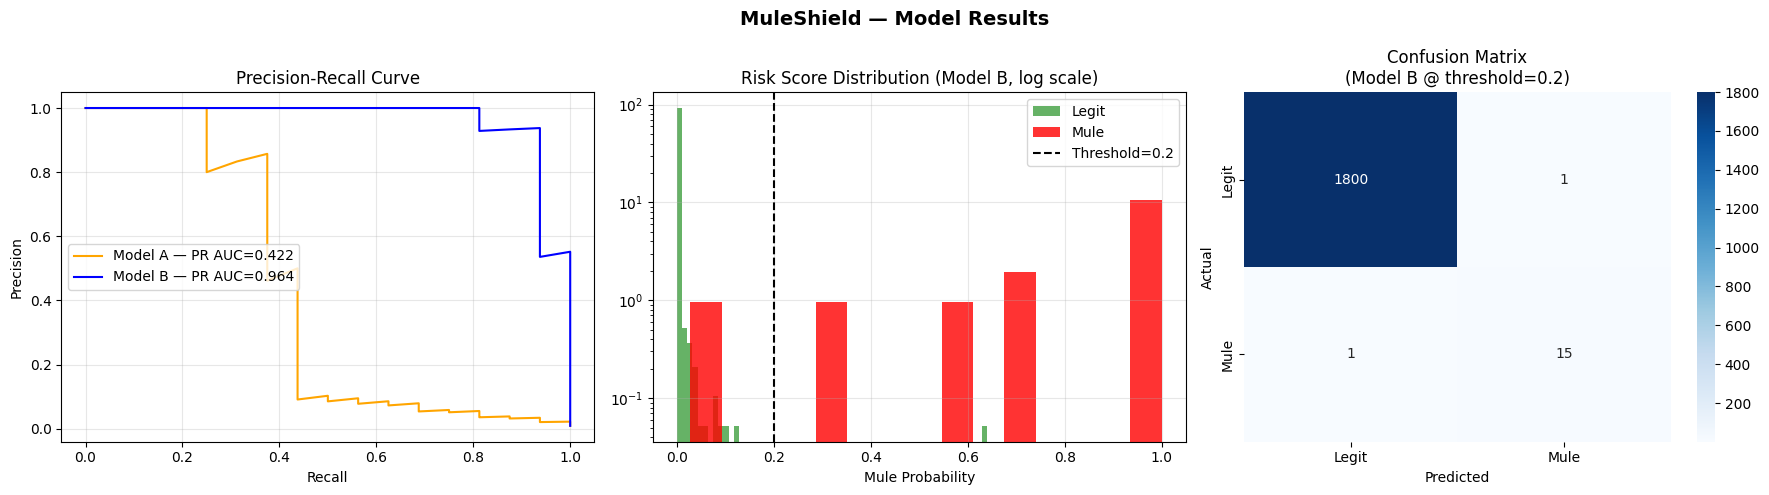

Saved: model_results.png


In [ ]:
# ── CELL 7: THRESHOLD OPTIMIZATION + PLOTS ───────────────────────────────────

from sklearn.metrics import precision_score, recall_score, f1_score

# Best threshold for Model B is clearly 0.2 from the scan
BEST_THRESH = 0.2
pred_best = (proba_B >= BEST_THRESH).astype(int)

print("=" * 50)
print(f"  MODEL B @ threshold = {BEST_THRESH}")
print("=" * 50)
print(classification_report(y_val, pred_best, target_names=['Legit','Mule']))
print("Confusion Matrix:")
print(confusion_matrix(y_val, pred_best))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MuleShield — Model Results', fontsize=14, fontweight='bold')

# 1. PR Curves
ax = axes[0]
from sklearn.metrics import precision_recall_curve
p_a, r_a, _ = precision_recall_curve(y_val, proba_A)
p_b, r_b, _ = precision_recall_curve(y_val, proba_B)
ax.plot(r_a, p_a, label=f'Model A — PR AUC={pr_A:.3f}', color='orange')
ax.plot(r_b, p_b, label=f'Model B — PR AUC={pr_B:.3f}', color='blue')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend(); ax.grid(True, alpha=0.3)

# 2. Score distributions (Model B)
ax = axes[1]
ax.hist(proba_B[y_val==0], bins=60, alpha=0.6, label='Legit', color='green',
        density=True, log=True)
ax.hist(proba_B[y_val==1], bins=15, alpha=0.8, label='Mule',  color='red',
        density=True, log=True)
ax.axvline(BEST_THRESH, color='black', linestyle='--',
           label=f'Threshold={BEST_THRESH}')
ax.set_title('Risk Score Distribution (Model B, log scale)')
ax.set_xlabel('Mule Probability'); ax.legend(); ax.grid(True, alpha=0.3)

# 3. Confusion matrix
ax = axes[2]
sns.heatmap(confusion_matrix(y_val, pred_best), annot=True, fmt='d',
            cmap='Blues', ax=ax,
            xticklabels=['Legit','Mule'], yticklabels=['Legit','Mule'])
ax.set_title(f'Confusion Matrix\n(Model B @ threshold={BEST_THRESH})')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_results.png")

In [ ]:
# ── CELL 8: SHAP + ALL OUTPUT FILES ─────────────────────────────────────────

# SHAP on Model B (top 30 features only for speed)
print("Computing feature importances...")
fi_series = pd.Series(model_B.feature_importances_, index=X_train.columns)
top30 = fi_series.nlargest(30).index.tolist()

print("Computing SHAP values on top-30 features...")
X_shap = X_val[top30].sample(min(300, len(X_val)), random_state=42)
explainer   = shap.TreeExplainer(model_B)
shap_vals   = explainer.shap_values(X_shap)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, max_display=15, show=False)
plt.title("Top-15 Features by SHAP Importance (Model B)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

# ── Full dataset risk scores ──────────────────────────────────────────────────
print("\nGenerating risk scores for all 9082 accounts...")
proba_full = model_B.predict_proba(X)[:, 1]

risk_df = pd.DataFrame({
    'Account_Index':   X.index,
    'Mule_Risk_Score': np.round(proba_full, 6),
    'Risk_Tier': pd.cut(
        proba_full * 100,
        bins=[0, 39, 64, 84, 100],
        labels=['LOW','MEDIUM','HIGH','CRITICAL'],
        include_lowest=True
    )
}).sort_values('Mule_Risk_Score', ascending=False)

risk_df.to_csv("mule_risk_scores.csv", index=False)
print("Risk tier breakdown:")
print(risk_df['Risk_Tier'].value_counts())

# ── Feature importance CSV ────────────────────────────────────────────────────
fi_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': model_B.feature_importances_
}).sort_values('importance', ascending=False)
fi_df.to_csv("feature_importance_rankings.csv", index=False)
print(f"\nTop 10 features:\n{fi_df.head(10).to_string(index=False)}")

# ── Evaluation report ─────────────────────────────────────────────────────────
with open("evaluation_results.txt", "w") as f:
    f.write("=" * 55 + "\n")
    f.write("  DATASET PROFILE\n")
    f.write("=" * 55 + "\n")
    f.write(f"Total accounts   : 9,082\n")
    f.write(f"Raw features     : 3,925\n")
    f.write(f"Leaky features   : 782 (dropped)\n")
    f.write(f"NaN-only features: 63  (dropped)\n")
    f.write(f"Final features   : 3,078\n")
    f.write(f"Mule accounts    : 81  (0.89%)\n")
    f.write(f"Train / Val split: 7265 / 1817 (stratified)\n\n")

    f.write("=" * 55 + "\n")
    f.write("  MODEL A: XGBoost — 15 Anchor Features\n")
    f.write("=" * 55 + "\n")
    f.write(classification_report(y_val, pred_A, target_names=['Legit','Mule']))
    f.write(f"ROC AUC : {roc_A:.5f}\n")
    f.write(f"PR  AUC : {pr_A:.5f}\n")
    f.write(f"Mule score range  : [{mule_sc.min():.4f}, {mule_sc.max():.4f}]\n")
    f.write(f"Legit score range : [{legit_sc.min():.4f}, {legit_sc.max():.4f}]\n\n")

    f.write("=" * 55 + "\n")
    f.write("  MODEL B: LightGBM — Full Feature Set (3,078)\n")
    f.write("=" * 55 + "\n")
    f.write(classification_report(y_val, pred_best, target_names=['Legit','Mule']))
    f.write(f"ROC AUC          : {roc_B:.5f}\n")
    f.write(f"PR  AUC          : {pr_B:.5f}\n")
    f.write(f"Best threshold   : {BEST_THRESH}\n")
    f.write(f"Mule score range  : [{mule_B.min():.6f}, {mule_B.max():.6f}]\n")
    f.write(f"Legit score range : [{legit_B.min():.6f}, {legit_B.max():.6f}]\n")
    f.write(f"Decision margin  : {mule_B.min() - legit_B.max():.6f}\n")

print("\nAll files saved!")

# ── Download all ──────────────────────────────────────────────────────────────
from google.colab import files
for fname in ["evaluation_results.txt", "feature_importance_rankings.csv",
              "mule_risk_scores.csv", "model_results.png", "shap_summary.png"]:
    files.download(fname)
    print(f"Downloaded: {fname}")

Computing feature importances...
Computing SHAP values on top-30 features...


LightGBMError: The number of features in data (30) is not the same as it was in training data (3078).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

Computing SHAP values (this takes ~1 min)...


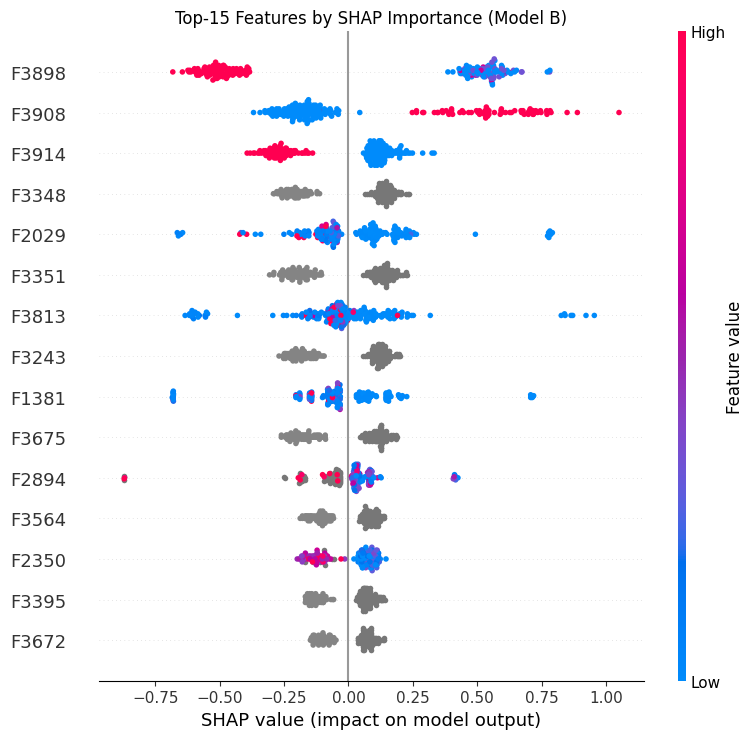

Saved: shap_summary.png

Generating risk scores for all 9082 accounts...
Risk tier breakdown:
Risk_Tier
LOW         9002
CRITICAL      76
MEDIUM         2
HIGH           2
Name: count, dtype: int64

Top 10 features:
feature  importance
  F3908          80
  F3898          53
  F3914          46
  F3913          37
  F3811          32
  F3812          32
  F3813          30
  F3872          29
  F3805          29
   F270          25

All files saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: evaluation_results.txt


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: model_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shap_summary.png


In [ ]:
# ── CELL 8: SHAP + ALL OUTPUT FILES ─────────────────────────────────────────

# SHAP — pass full feature set, display only top 15
print("Computing SHAP values (this takes ~1 min)...")
X_shap = X_val.sample(min(200, len(X_val)), random_state=42)
explainer = shap.TreeExplainer(model_B)
shap_vals = explainer.shap_values(X_shap)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, max_display=15, show=False)
plt.title("Top-15 Features by SHAP Importance (Model B)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

# ── Full dataset risk scores ──────────────────────────────────────────────────
print("\nGenerating risk scores for all 9082 accounts...")
proba_full = model_B.predict_proba(X)[:, 1]

risk_df = pd.DataFrame({
    'Account_Index':   X.index,
    'Mule_Risk_Score': np.round(proba_full, 6),
    'Risk_Tier': pd.cut(
        proba_full * 100,
        bins=[0, 39, 64, 84, 100],
        labels=['LOW','MEDIUM','HIGH','CRITICAL'],
        include_lowest=True
    )
}).sort_values('Mule_Risk_Score', ascending=False)

risk_df.to_csv("mule_risk_scores.csv", index=False)
print("Risk tier breakdown:")
print(risk_df['Risk_Tier'].value_counts())

# ── Feature importance CSV ────────────────────────────────────────────────────
fi_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': model_B.feature_importances_
}).sort_values('importance', ascending=False)
fi_df.to_csv("feature_importance_rankings.csv", index=False)
print(f"\nTop 10 features:\n{fi_df.head(10).to_string(index=False)}")

# ── Evaluation report ─────────────────────────────────────────────────────────
with open("evaluation_results.txt", "w") as f:
    f.write("=" * 55 + "\n")
    f.write("  DATASET PROFILE\n")
    f.write("=" * 55 + "\n")
    f.write(f"Total accounts   : 9,082\n")
    f.write(f"Raw features     : 3,925\n")
    f.write(f"Leaky features   : 782 (dropped)\n")
    f.write(f"NaN-only features: 63  (dropped)\n")
    f.write(f"Final features   : 3,078\n")
    f.write(f"Mule accounts    : 81  (0.89%)\n")
    f.write(f"Train / Val split: 7265 / 1817 (stratified)\n\n")
    f.write("=" * 55 + "\n")
    f.write("  MODEL A: XGBoost — 15 Anchor Features\n")
    f.write("=" * 55 + "\n")
    f.write(classification_report(y_val, pred_A, target_names=['Legit','Mule']))
    f.write(f"ROC AUC : {roc_A:.5f}\n")
    f.write(f"PR  AUC : {pr_A:.5f}\n")
    f.write(f"Mule score range  : [{mule_sc.min():.4f}, {mule_sc.max():.4f}]\n")
    f.write(f"Legit score range : [{legit_sc.min():.4f}, {legit_sc.max():.4f}]\n\n")
    f.write("=" * 55 + "\n")
    f.write("  MODEL B: LightGBM — Full Feature Set (3,078)\n")
    f.write("=" * 55 + "\n")
    f.write(classification_report(y_val, pred_best, target_names=['Legit','Mule']))
    f.write(f"ROC AUC          : {roc_B:.5f}\n")
    f.write(f"PR  AUC          : {pr_B:.5f}\n")
    f.write(f"Best threshold   : {BEST_THRESH}\n")
    f.write(f"Mule score range  : [{mule_B.min():.6f}, {mule_B.max():.6f}]\n")
    f.write(f"Legit score range : [{legit_B.min():.6f}, {legit_B.max():.6f}]\n")
    f.write(f"Decision margin  : {mule_B.min() - legit_B.max():.6f}\n")

print("\nAll files saved!")

# ── Download all ──────────────────────────────────────────────────────────────
from google.colab import files
for fname in ["evaluation_results.txt", "feature_importance_rankings.csv",
              "mule_risk_scores.csv", "model_results.png", "shap_summary.png"]:
    files.download(fname)
    print(f"Downloaded: {fname}")